# Type-Lowering: Å bygge et grid for $D$

Denne notebooken demonstrerer hvordan vi kan representere den felles sannheten ($D$) som en matrise, og ikke en sekvens. 
Dette er selve kjernen i 'Type-Lowering': All informasjon (både lyd og bilde) senkes ned til et rutenett (posisjonsfelt) av metrisk tid og tonehøyde.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)

## 1. Definere domenet $D$

Vi oppretter et tomt grid for $D_{onset}$. 
- **X-aksen ($t$):** Logisk/metrisk tid. La oss si vi har 4 takter i 4/4-takt, oppløst i 16-delsnoter. Det gir $4 \times 4 \times 4 = 64$ tids-kolonner.
- **Y-aksen ($p$):** Logisk pitch. Vi bruker MIDI-verdier, f.eks. fra C4 (60) til C6 (84). Det gir 25 pitch-rader.

In [2]:
# Parametere for gridet
num_time_steps = 64
min_midi = 60
max_midi = 84
num_pitches = max_midi - min_midi + 1

# Gridet D_onset (sannsynlighetsmatrise initialisert med nuller)
D_onset = np.zeros((num_pitches, num_time_steps))

## 2. Posisjonell evidens fra Bilde ($U_{image}$)

La oss si at bildegjenkjenningen (OMR) finner et notehode som den *tror* er en E4 (MIDI 64) på første slaget i takt 2 (tids-steg 16). OMR er ofte usikker på rytmen hvis notene står tett. Vi legger dette inn som en Gaussisk fordeling over tid og pitch.

In [3]:
def add_evidence(grid, time_idx, pitch_midi, weight, time_spread=1, pitch_spread=0):
    pitch_idx = pitch_midi - min_midi
    for t in range(max(0, time_idx - time_spread), min(num_time_steps, time_idx + time_spread + 1)):
        for p in range(max(0, pitch_idx - pitch_spread), min(num_pitches, pitch_idx + pitch_spread + 1)):
            # Enkel distanse-vekt for å lage en 'blob'
            distance = np.sqrt(((t - time_idx)/max(1, time_spread))**2 + ((p - pitch_idx)/max(1, pitch_spread))**2)
            if distance <= 1:
                grid[p, t] += weight * (1 - distance)

# Bilde-evidens: Note ved MIDI 64, tid 16. Høy visuell pitch-sikkerhet, men usikker rytme (bred i x-aksen).
add_evidence(D_onset, time_idx=16, pitch_midi=64, weight=0.6, time_spread=3, pitch_spread=0)

# Enda en note fra bildet: MIDI 67, tid 32
add_evidence(D_onset, time_idx=32, pitch_midi=67, weight=0.6, time_spread=2, pitch_spread=0)

## 3. Posisjonell evidens fra Lyd ($U_{audio}$)

Nå simulerer vi hva spektrogrammet / onset-detectoren vår gir oss. Den har perfekt timing, men kan være litt usikker på akkurat hvilken pitch (grunnet overtoner / oppløsning i frekvens).

In [4]:
# Lyd-evidens: Hører et anslag nøyaktig på tid 15 (bildet trodde tid 16!), rundt MIDI 64.
add_evidence(D_onset, time_idx=15, pitch_midi=64, weight=0.7, time_spread=0, pitch_spread=1)

# Lyd-evidens: Hører anslag nøyaktig på tid 32, rundt MIDI 67.
add_evidence(D_onset, time_idx=32, pitch_midi=67, weight=0.7, time_spread=0, pitch_spread=1)


## 4. Fusjon og Kollaps til fasit

Begge modalitetene har nå injisert sin evidens inn i det samme rutenettet. Resultatet er en fusjonert matrise. Der bilde og lyd er enige, forsterkes signalet.

Til slutt "kollapser" vi bølgen ved å finne toppunktene i rutenettet. Det er *disse* koordinatene som eksporteres som sekvensiell `**kern`!

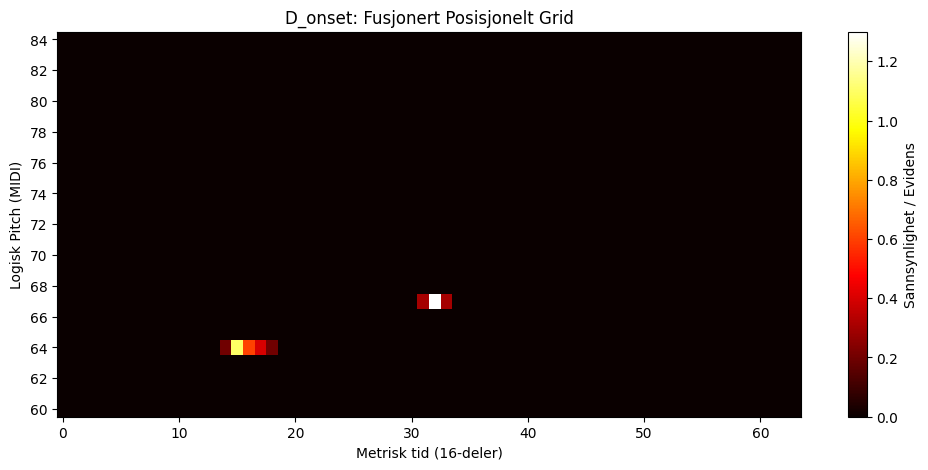

Sensor Fusion kollaps for første note: Pitch = 64, Tid = 15


In [5]:
plt.figure(figsize=(12, 5))
plt.imshow(D_onset, aspect='auto', origin='lower', cmap='hot', interpolation='nearest')
plt.colorbar(label='Sannsynlighet / Evidens')
plt.yticks(ticks=np.arange(0, num_pitches, 2), labels=np.arange(min_midi, max_midi+1, 2))
plt.xlabel('Metrisk tid (16-deler)')
plt.ylabel('Logisk Pitch (MIDI)')
plt.title('D_onset: Fusjonert Posisjonelt Grid')
plt.show()

# Finn toppunktet rundt den første noten
t_window = D_onset[:, 10:20]
best_p, best_t_local = np.unravel_index(np.argmax(t_window), t_window.shape)
best_t = 10 + best_t_local
print(f"Sensor Fusion kollaps for første note: Pitch = {min_midi + best_p}, Tid = {best_t}")
# Legg merke til at siden bildet sa tid 16 (med spread), 
# men lyden sa tid 15 (uten spread), lander fusjonen trygt på tid 15!